## Idea here

- edit this with our handy functions in fullaste_run_config.py to make sure this is compatible for three runs:
- one miniASTE, one ASTE 270, one lab sea config

- to run: change dt, change tsstr and datetimes depending on run, change myparms if needed

## packages and functions

In [147]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import xarray as xr
import h5py
from scipy.io import loadmat
import matplotlib as mpl
import time
import gsw
from matplotlib.colors import TwoSlopeNorm

# import existing python files
plt.rcParams['figure.figsize'] = (10,4)

# add rdmds reading functions to path
sys.path.append("/home/mmurakami/MITgcm/MITgcm_c68r/MITgcm-checkpoint68r/utils/python/MITgcmutils/MITgcmutils/") # go to parent dir
from mds import *

# add the other files
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
from read_binary import *
from calc_UV_conv_1face import calc_UV_conv_1face
from calc_mskmean_T_mod import calc_mskmean_T_mod
from mk3D_mod import mk3D_mod
from aste_helper_funcs import *
from timing_functions import *           # ts2dte, get_fnames, etc.
from binning import *                    # bin_array, create_mesh

### Read grid and masks

In [249]:
# define tsstr to read from for this, can work for all

# create an array of the time steps we want to read
# use ts2dte to get december 2014
# first make an array of filenames
dt = 600
startyr = 2002
endyr = 2019

# all the filenames in the system
fnames = get_fnames(dt,startyr,endyr)

times = {}
times["2014"] = np.arange(3,5,1)

# the filenames we want for 2014
tsstr,datetimes = get_tsteps(times,fnames,dt,startyr,1,1)
t1 = int(tsstr[0])
t2 = int(tsstr[1])
print(tsstr)
dt = datetimes[1]-datetimes[0]   # days
dt = dt.total_seconds()
dt

['0000639648' '0000644112']


2678400.0

In [250]:
from fullaste_run_config import configure_import_paths, install_fullaste_config
configure_import_paths()

In [251]:
# this will setup myparms unless we want to define them differently

# cfg = install_fullaste_config(
#     globals(),
#     profile="aste90",  # "aste270", "aste90", or "labsea"
#     budget="Mass",     # "Mass", "Heat", or "Salt"
#     dirroot="/scratch3/atnguyen/aste_90x150x60/",
#     runstr="run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001_r8_07May2026_pfe/",
#     tsstr = ["0000000003", "0000000004"],
# )

# cfg = install_fullaste_config(
#     globals(),
#     profile="labsea",
#     budget="Mass",
#     dirroot="/scratch/mmurakami/labsea/layers/",
#     dirGrid="/scratch2/atnguyen/labsea/GRID_r8/",
#     runstr="run_c68v_layers_lessmem1_5ts_06May2026/",
#     tsstr=["0000000003", "0000000004"],
# )

cfg = install_fullaste_config(
    globals(),
    profile="aste270",
    budget="Mass",
    dirroot="/scratch2/atnguyen/aste_270x450x180/",
    dirrun="/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019/",
    tsstr = tsstr
)

In [252]:
print(oneface)
print(bigaste)

False
True


In [253]:
# save myParms from An hard-coding
save_budg_3d = 0
save_budg_2d = 1
save_budg_scalar = 0
save_budg_lev = 0

strbudg = 'Mass'
kBudget = 1
test3d = True
plot_fig = 1
# kz = [[1, 5], [6, 10], [11, 19], [20, 23]]

myparms = {
    'yearFirst': 1979,
    'yearLast': 1979,
    'yearInAv': [1979, 1979],
    'timeStep': 86400,      # needs to be changed depending on the run
    'iceModel': 1,
    'useRFWF': 1,
    'useNLFS': 4,
    'rStar': 2,
    'rhoconst': 1029,
    'rcp': 1029 * 3994,    # reference seawater specific heat capacity (1029 kg/m^3) * (3994 J/kg K) = J/(m^3*degC)
    'rhoi': 910,
    'rhosn': 330,
    'flami': 334000,
    'flamb': 2500000,
    'SIsal0': 4,
    'diagsAreMonthly': 0,
    'diagsAreAnnual': 0,
    'recInAve': [1, 2],
    'SaltPlumeHeatFlux': 0,  # Not sure what this is
    'conserveTr': 0
}

# dt = myparms['timeStep']
dt = 2678400

In [254]:
from fullaste_run_config import load_mygrid, prepare_grid_metrics, apply_aste_open_boundary_mask

mygrid = load_mygrid(
    rdmds,
    dirGrid,
    nx=nx,
    ny=ny,
    nz=nz,
    oneface=oneface,
    facesSize=globals().get("facesSize"),
    facesExpand=globals().get("facesExpand"),
)

metrics = prepare_grid_metrics(mygrid, mk3D_mod, nz=nz, ny=ny, nx=nx)
globals().update(metrics)

if not oneface:
    hf = apply_aste_open_boundary_mask(
        mygrid["hFacC"],
        nx=nx,
        nz=nz,
        nfx=nfx,
        nfy=nfy,
        get_aste_tracer_func=get_aste_tracer,
        aste_tracer2compact_func=aste_tracer2compact,
    )
else:
    hf = mygrid["hFacC"].copy()
    hf[hf == 0] = np.nan

mygrid['mskC'][mygrid['mskC'] == 0] = np.nan

areaW, areaS, Vol = [], [], []
for k in range(nz):
    areaW.append(mygrid['DYG'] * mygrid['DRF'][k])
    areaS.append(mygrid['DXG'] * mygrid['DRF'][k])
    Vol.append(mygrid['RAC'] * mygrid['DRF'][k])

### mass tendency

In [255]:
# ocean and ice
AB_gT=0
AB_gS=0
# ffac = 1e-6
ffac = 1

In [256]:
# from fullaste_run_config.py import diagnostic_file_map(layers_path)

file_name = 'budg2d_snap_set1'
meta_budg2d_snap_set1 = parsemeta(dirIn + file_name + "." + tsstr[0] + ".meta")

# try to read this with rec
fldlist = np.array(meta_budg2d_snap_set1['fldList'])
varnames = np.array(['ETAN','PHIBOT','SIheff','SIhsnow'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])

ETAN = np.full((len(tsstr),ny,nx),np.nan)
PHIBOT = np.full((len(tsstr),ny,nx),np.nan)
SIheff = np.full((len(tsstr),ny,nx),np.nan)
SIhsnow = np.full((len(tsstr),ny,nx),np.nan)

for i in range(len(tsstr)):
    thisETAN,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[0])
    thisETAN = thisETAN.reshape(ny,nx)
    ETAN[i] = thisETAN

    thisPHIBOT,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[1])
    thisPHIBOT = thisPHIBOT.reshape(ny,nx)
    PHIBOT[i] = thisPHIBOT

    thisSIheff,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[2])
    thisSIheff = thisSIheff.reshape(ny,nx)
    SIheff[i] = thisSIheff

    thisSIhsnow,its,meta = rdmds(os.path.join(dirIn, file_name),int(tsstr[i]),returnmeta=True,rec=recs[3])
    thisSIhsnow = thisSIhsnow.reshape(ny,nx)
    SIhsnow[i] = thisSIhsnow

ETAN =  (ETAN[1, :, :] - ETAN[0, :, :]) / dt
PHIBOT = (PHIBOT[1, :, :] - PHIBOT[0, :, :]) / dt
SIheff =  (SIheff[1, :, :] - SIheff[0, :, :]) / dt
SIhsnow = (SIhsnow[1, :, :] - SIhsnow[0, :, :]) / dt

In [257]:
# 3D, with rStar:
# mk3D_mod function should be called here but I might be doing it wrong

if myparms['useNLFS'] < 2 or myparms['rStar'] == 0:        # not this time
    tmptend = np.zeros((nz, ny, nx))
    tmptend[0,:, :] = ETAN * myparms['rhoconst'] * RAC    # m/s * kg/m^3 * m  = kg/s
    if myparms['useRFWF'] == 0:
        tmptend[0, :, :] = np.zeros((ny, nx))
else:
    if myparms['useRFWF'] != 0:                                 # we are using this  # check if tmp1 is the same as drf3d!!
        tmp1 = mk3D_mod(mygrid['DRF'],hfC) * hfC           # m^2
        tmp2 = tmp1/mk3D_mod(DD,tmp1)
    else:
        tmp2 = drf3d / mk3D_mod(DD, tmp1)
        
    tmptend = tmp2 * np.tile(ETAN[np.newaxis,:,:],(nz,1,1)) * myparms['rhoconst'] * RAC3
    


In [258]:
budgO = {}
budgO = {'fluxes': {'tend': tmptend}}
budgO['tend'] = np.nansum(tmptend,axis=0)
budgI = {'tend': (SIheff * myparms['rhoi'] + SIhsnow * myparms['rhosn'] * RAC)}

In [259]:
# budgI = {'tend': (SIheff * myparms['rhoi'] + SIhsnow * myparms['rhosn']) * RAC}
budgOI = {}
budgOI['tend'] = budgO['tend'] + budgI['tend']

### Calculate horizontal convergence
We used to do this with calc_UV_conv_1face but now we just want totally the calc_UV

In [260]:
# read U and V mass
# read U and V mass: first try budg, then trsp
UVELMASS = None
VVELMASS = None

sources = [
    (dirIn,   "budg3d_hflux_set2"),
    (dirtrsp, "trsp_3d_set1")
]

for src_dir, fname in sources:
    try:
        meta_file = parsemeta(src_dir + fname + '.' + tsstr[1] + '.meta')
        fldlist = np.array(meta_file['fldList'])

        if not all(var in fldlist for var in ['UVELMASS', 'VVELMASS']):
            continue

        urec = np.where(fldlist == 'UVELMASS')[0][0]
        vrec = np.where(fldlist == 'VVELMASS')[0][0]

        UVELMASS, its, meta = rdmds(
            src_dir + fname,
            int(tsstr[1]),
            returnmeta=True,
            rec=urec
        )

        VVELMASS, its, meta = rdmds(
            src_dir + fname,
            int(tsstr[1]),
            returnmeta=True,
            rec=vrec
        )

        print(f"Loaded UVELMASS and VVELMASS from {fname}")
        break

    except (FileNotFoundError, OSError, KeyError, IndexError):
        continue

if UVELMASS is None or VVELMASS is None:
    raise ValueError(
        f"UVELMASS/VVELMASS not found in budg3d_hflux_set2 or "
        f"trsp_3d_set1 for timestep {tsstr[1]}"
    )

# read advective
meta_budg2d_hflux_set1= parsemeta(dirIn + "budg2d_hflux_set1" + '.' + tsstr[1] + '.meta')
fldlist = np.array(meta_budg2d_hflux_set1['fldList'])
varnames = np.array(['ADVxHEFF','ADVyHEFF','ADVxSNOW','ADVySNOW'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVxHEFF,its,meta = rdmds(dirIn + "budg2d_hflux_set1", int(tsstr[1]),returnmeta=True,rec = recs[0])       # m.m^2/s    ice 
ADVyHEFF,its,meta = rdmds(dirIn + "budg2d_hflux_set1", int(tsstr[1]),returnmeta=True,rec = recs[1])       # m.m^2/s    ice 
ADVxSNOW,its,meta = rdmds(dirIn + "budg2d_hflux_set1", int(tsstr[1]),returnmeta=True,rec = recs[2])       # m.m^2/s    snow
ADVySNOW,its,meta = rdmds(dirIn + "budg2d_hflux_set1", int(tsstr[1]),returnmeta=True,rec = recs[3])


UVELMASS = UVELMASS.reshape(nz,ny,nx)
VVELMASS = VVELMASS.reshape(nz,ny,nx)
ADVxHEFF = ADVxHEFF.reshape(ny,nx)
ADVyHEFF = ADVyHEFF.reshape(ny,nx)
ADVxSNOW = ADVxSNOW.reshape(ny,nx)
ADVySNOW = ADVySNOW.reshape(ny,nx)

Loaded UVELMASS and VVELMASS from budg3d_hflux_set2


In [261]:
# THERE IS NO DFXEHEFF OR DFYEHEFF! This has not been handled in this notebook
# Calculations for ocean
tmpUo = myparms['rhoconst'] * dyg3d * drf3d * UVELMASS    # m/s * m * m * kg/m^3 = kg/s
tmpVo = myparms['rhoconst'] * dxg3d * drf3d * VVELMASS    # kg/s

# replace tmpUo and tmpVo with the faces here
if not oneface:
    tmpUo = get_aste_faces(tmpUo,nfx,nfy)              
    tmpVo = get_aste_faces(tmpVo,nfx,nfy)
    
    # tmpUo,tmpVo = get_aste_vector_face1_3(tmpUo,tmpVo,nfx,nfy,False)
    conv = calc_UV_conv_mod(nfx,nfy,tmpUo,tmpVo) #[:,:-1,:-1]
else:
    conv = calc_UV_conv_1face(tmpUo,tmpVo) #[:,:-1,:-1]

In [262]:
# tmptendf = get_aste_faces(budgO['fluxes']['hconv'],nfx,nfy)
# vlev = np.nanmax(tmptendf.f3[0])
# plt.pcolormesh(tmptendf.f3[0],cmap='seismic',vmin=-vlev,vmax=vlev)
# plt.colorbar()

In [263]:
budgO['fluxes']['hconv'] = conv

if not oneface:
    budgO['hconv'] = calc_UV_conv_mod(nfx,nfy,np.nansum(tmpUo, axis=0), np.nansum(tmpVo, axis=0))
else:
    budgO['hconv'] = calc_UV_conv_1face(np.nansum(tmpUo, axis=0), np.nansum(tmpVo, axis=0))

### Calculate vertical convergence

In [264]:
# rewrite with only reading in these lines, be sure to compare
meta_budg2d_zflux_set1= parsemeta(dirIn + "budg2d_zflux_set1" + '.' + tsstr[1] + '.meta')
fldlist = np.array(meta_budg2d_zflux_set1['fldList'])
varnames = np.array(['oceFWflx','SIatmFW'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
# net surface Fresh-Water flux into the ocean (+=down), >0 decreases salinity
oceFWflx,its,meta = rdmds(dirIn + "budg2d_zflux_set1", int(tsstr[1]),returnmeta=True,rec = recs[0])
# Net freshwater flux from atmosphere & land (+=down)
SIatmFW,its,meta = rdmds(dirIn + "budg2d_zflux_set1", int(tsstr[1]),returnmeta=True,rec = recs[1])

oceFWflx = oceFWflx.reshape(ny,nx)                     # kg/m^2/s
SIatmFW = SIatmFW.reshape(ny,nx)                       # kg/m^2/s


# read WVELMASS -- needs to check two files
WVELMASS = None

for fname in ["budg3d_zflux_set2", "budg3d_kpptend_set1"]:

    try:
        meta_file = parsemeta(
            dirIn + fname + '.' + tsstr[1] + '.meta'
        )

        fldlist = np.array(meta_file['fldList'])

        if 'WVELMASS' not in fldlist:
            continue

        rec = np.where(fldlist == 'WVELMASS')[0][0]

        # Vertical Mass-Weighted Comp of Velocity
        WVELMASS, its, meta = rdmds(
            dirIn + fname,
            int(tsstr[1]),
            returnmeta=True,
            rec=rec
        )

        # kpptend file comes back flattened
        if fname == "budg3d_kpptend_set1":
            WVELMASS = WVELMASS.reshape(nz, ny, nx)

        print(f"Loaded WVELMASS from {fname}")
        break

    except (FileNotFoundError, OSError, KeyError, IndexError):
        continue

if WVELMASS is None:
    raise ValueError(
        f"WVELMASS not found in either budg3d_zflux_set2 or "
        f"budg3d_kpptend_set1 for timestep {tsstr[1]}"
    )
    
WVELMASS = WVELMASS.reshape(nz,ny,nx)

Loaded WVELMASS from budg3d_zflux_set2


In [265]:
# Perform calculations
budgO["zconv"] = oceFWflx                               # kg/m^2/s
budgI["zconv"] = SIatmFW - oceFWflx

if not myparms["useRFWF"]:
    budgO["zconv"] = 0 * budgO["zconv"]

trWtop = -WVELMASS * myparms["rhoconst"]                # m/s * kg/m^3 = kg/m^2/s
print(trWtop.shape)

if myparms["useNLFS"] < 2 or myparms["rStar"] == 0:
    trWtop[0, :, :] = oceFWflx
    if not myparms["useRFWF"]:
        print("debug")
        trWtop[0,:, :] = -WVELMASS[0,:, :] * myparms["rhoconst"]

# same size trWtop and TrWbot
trWbot = np.zeros_like(trWtop)
trWbot[:-1,:, :] = trWtop[1:,:, :]

#budgO["fluxes"] = {}
budgO["fluxes"]["trWtop"] = trWtop * RAC3            # kg/s
budgO["fluxes"]["trWbot"] = trWbot * RAC3
budgO["fluxes"]["zconv"] = budgO["fluxes"]["trWtop"] - budgO["fluxes"]["trWbot"]

# changed axis here to 0 because we're looking at z
if myparms["useNLFS"] < 2 or (myparms["rStar"] == 0 and not myparms["useRFWF"]):
    budgO["zconv"] += np.sum(trWtop - trWbot, axis=0)

budgI["fluxes"] = {}
budgI["fluxes"]["trWtop"] = -RAC * (budgI["zconv"] + budgO["zconv"])
budgI["fluxes"]["trWbot"] = -RAC * budgO["zconv"]

budgO["zconv"] = RAC * budgO["zconv"]
budgI["zconv"] = RAC * budgI["zconv"]
budgOI["zconv"] = budgO["zconv"] + budgI["zconv"]

(50, 1350, 270)


### Is this budgeted in horizontal space?

In [266]:
zlev = 4

j, i = np.where(mygrid['hFacC'][zlev, :, :] > 0)

npts = 2
idx = np.random.choice(len(i), size=npts, replace=False)

pt = np.column_stack([
    i[idx],
    j[idx],
    np.full(npts, zlev)
])

print(pt)

[[50 36  4]
 [ 9 85  4]]


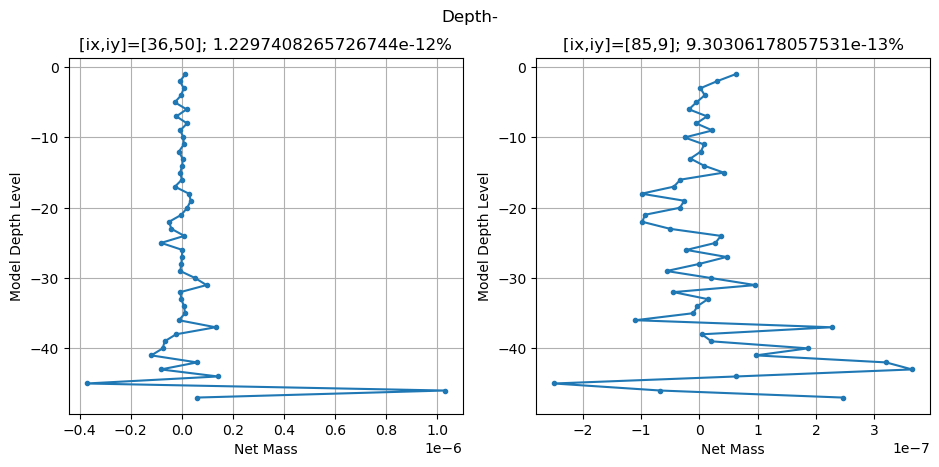

In [267]:
# Figure 1
plt.figure(1, figsize=(9.5, 8.5))
aa = np.zeros((nz, 4))
plt.suptitle("Depth-")

# four figures labeled n
for n in range(1, 3):
    ix, iy, k = pt[n-1]
    aa[:, n-1] = budgO['fluxes']['tend'][:, iy, ix] - budgO['fluxes']['zconv'][:, iy, ix] - budgO['fluxes']['hconv'][:, iy, ix]
    #aa[:, n-1] = budgO['tend'][iy, ix] - budgO['hconv'][0,iy, ix] - budgO['zconv'][iy, ix]

    plt.subplot(2, 2, n)
    plt.plot(aa[:, n-1], -np.arange(1, nz+1), '.-')
    plt.grid()
    #plt.xlabel(f"net budg{strbudg[0]}o")
    plt.xlabel("Net Mass")
    plt.ylabel("Model Depth Level")
    plt.title(f"[ix,iy]=[{iy},{ix}]; {100 * np.nanmax(np.abs(aa[:, n-1]))/np.nanmax(np.abs(budgO['fluxes']['zconv'][:,iy, ix]))}%")
        
plt.tight_layout()
plt.show()

In [268]:
a = budgO['fluxes']['tend'] * np.tile(mygrid['hFacC'][0][np.newaxis,:, :], (nz, 1, 1))
b = budgO['fluxes']['hconv'] * np.tile(mygrid['hFacC'][0][np.newaxis,:, :], (nz, 1, 1))
c = budgO['fluxes']['zconv'] * np.tile(mygrid['hFacC'][0][np.newaxis,:, :], (nz, 1, 1))

a[np.isnan(a)] = 0
b[np.isnan(b)] = 0
c[np.isnan(c)] = 0

In [269]:
# def get_vlev(values):
#     return(np.abs(np.nanmax(values)))

# # double check face edge

# myk = 0
# fig = plt.figure()

# ax = plt.subplot(221)
# vlev = get_vlev(budgO['fluxes']['tend'][myk])
# ax.pcolormesh(budgO['fluxes']['tend'][myk],cmap='seismic',vmin=-vlev,vmax=vlev)

# ax = plt.subplot(222)
# vlev = get_vlev(budgO['fluxes']['hconv'][myk])
# ax.pcolormesh(budgO['fluxes']['hconv'][myk],cmap='seismic',vmin=-vlev,vmax=vlev)

# ax = plt.subplot(223)
# vlev = get_vlev(budgO['fluxes']['zconv'][myk])
# ax.pcolormesh(budgO['fluxes']['zconv'][myk],cmap='seismic',vmin=-vlev,vmax=vlev)

# ax = plt.subplot(224)
# resid = budgO['fluxes']['tend'] - budgO['fluxes']['hconv'] - budgO['fluxes']['zconv']
# vlev = get_vlev(resid[myk])
# cb = ax.pcolormesh(resid[myk],cmap='seismic',vmin=-vlev,vmax=vlev)
# plt.colorbar(cb)

In [270]:
# def get_vlev(values):
#     return(0.01*np.abs(np.nanmax(values)))

# # double check face edge

# myk = 0
# fig = plt.figure()

# ax = plt.subplot(221)
# vlev = get_vlev(budgO['fluxes']['tend'][myk])
# cb = ax.pcolormesh(get_aste_tracer(budgO['fluxes']['tend'],nfx,nfy)[myk],cmap='seismic',vmin=-vlev,vmax=vlev)
# ax.set_xlim(130,180)
# ax.set_ylim(100,200)
# plt.colorbar(cb)

# ax = plt.subplot(222)
# vlev = get_vlev(budgO['fluxes']['hconv'][myk])
# cb = ax.pcolormesh(get_aste_tracer(budgO['fluxes']['hconv'],nfx,nfy)[myk],cmap='seismic',vmin=-vlev,vmax=vlev)
# ax.set_xlim(130,180)
# ax.set_ylim(100,200)
# plt.colorbar(cb)

# ax = plt.subplot(223)
# vlev = get_vlev(budgO['fluxes']['zconv'][myk])
# cb = ax.pcolormesh(get_aste_tracer(budgO['fluxes']['zconv'],nfx,nfy)[myk],cmap='seismic',vmin=-vlev,vmax=vlev)
# ax.set_xlim(130,180)
# ax.set_ylim(100,200)
# plt.colorbar(cb)

# ax = plt.subplot(224)
# resid = budgO['fluxes']['tend'] - budgO['fluxes']['hconv'] - budgO['fluxes']['zconv']
# vlev = get_vlev(resid[myk])
# cb = ax.pcolormesh(get_aste_tracer(resid,nfx,nfy)[myk],cmap='seismic',vmin=-1e-7,vmax=1e-7)
# ax.set_xlim(130,180)
# ax.set_ylim(100,200)
# plt.colorbar(cb)

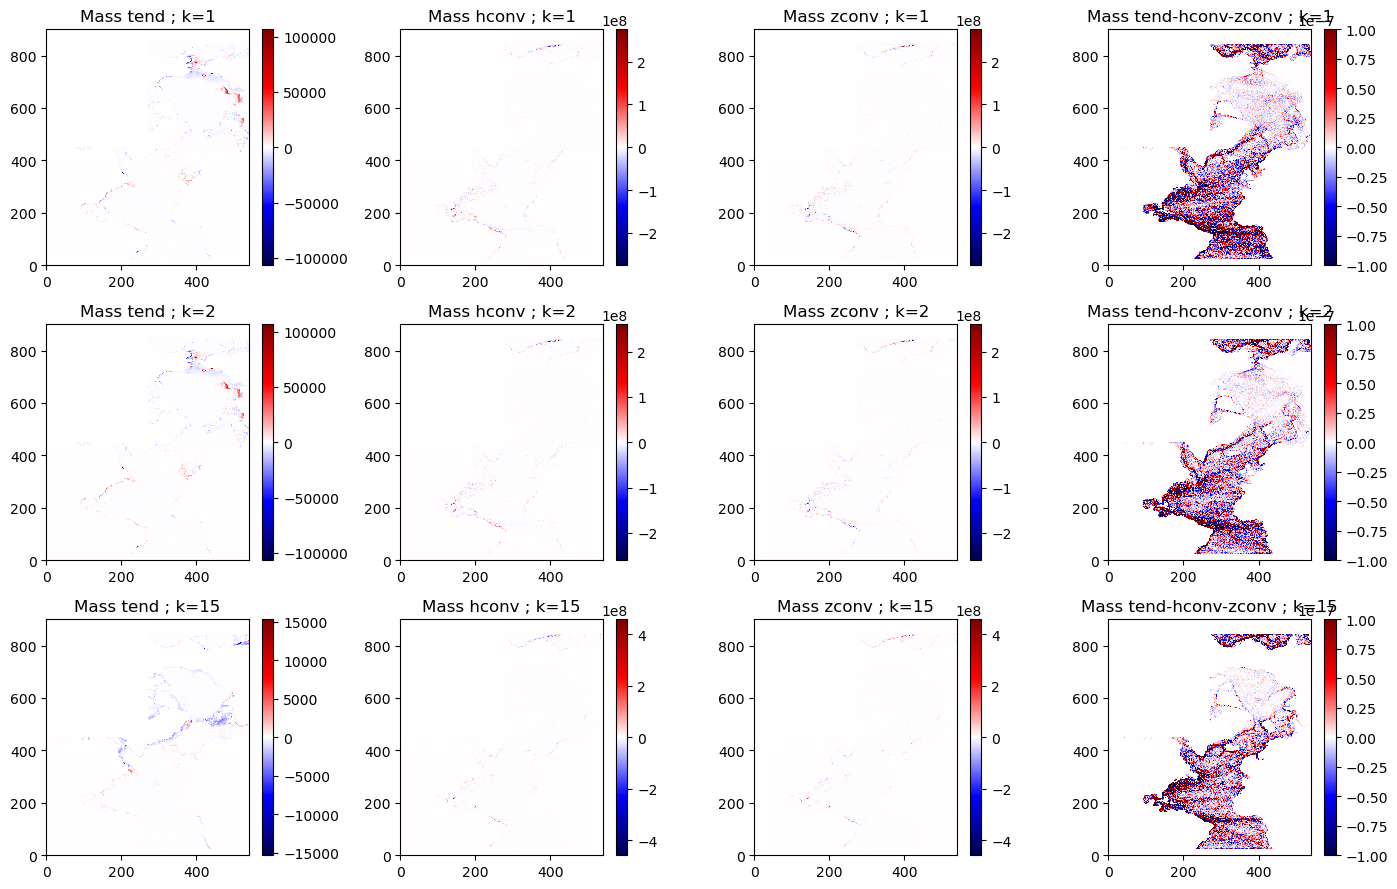

In [271]:
# Figure 2

klev = [1, 2, 15]
fig, axes = plt.subplots(len(klev), 4, figsize=(14, 3 * len(klev)))

# handles case where len(klev) == 1
axes = np.atleast_2d(axes)

for idx, k1 in enumerate(klev):
    str_k = f"; k={k1}"

    fields = [
        (a, 'tend'),
        (b, 'hconv'),
        (c, 'zconv'),
        (a - b - c, 'tend-hconv-zconv')
    ]

    for j, (data, title) in enumerate(fields):
        ax = axes[idx, j]

        raw = data[k1 - 1, :, :]

        if oneface:
            mydata = raw
        else:
            mydata = get_aste_tracer(raw, nfx, nfy)[0]

        if title == 'tend-hconv-zconv':
            pcm = ax.pcolormesh(
                mydata,
                cmap='seismic',
                vmin=-1e-7,
                vmax=1e-7
            )
        else:
            vmax = 0.99 * np.nanmax(np.abs(raw))
            pcm = ax.pcolormesh(
                mydata,
                cmap='seismic',
                vmin=-vmax,
                vmax=vmax
            )

        fig.colorbar(pcm, ax=ax)

        ax.set_title(f"{strbudg} {title} {str_k}")

        # works for any ny, nx
        ax.set_xlim(0, mydata.shape[1])
        ax.set_ylim(0, mydata.shape[0])

plt.tight_layout()
plt.show()

# great, this is budgeted, now we can move on to heat and try to create the vectors